Task was destroyed but it is pending!
task: <Task pending name='Task-149' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at C:\Users\J.VIGNESH\AppData\Local\Programs\Python\Python310\lib\site-packages\ipykernel\utils.py:76> wait_for=<Task pending name='Task-150' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\J.VIGNESH\AppData\Local\Programs\Python\Python310\lib\site-packages\ipykernel\utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\J.VIGNESH\AppData\Local\Programs\Python\Python310\lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Exception ignored in: <coroutine object _async_in_context.<locals>.preserve_context at 0x0000023B24DF6B20>
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyError: '__import__'
Exception ignored in: <coroutine object _async_in_context.<locals>.preserve_context at 0x0000023B24DF6B20>
Traceback (most recent call last):
  File "<string>

CSV file not found.
Creating sample diabetes dataset for demonstration...

Dataset Sample:
      Glucose        BMI
0  134.901425  34.146724
1  115.852071  35.364707
2  139.430656  38.498307
3  165.690896  38.322812
4  112.975399  23.733984


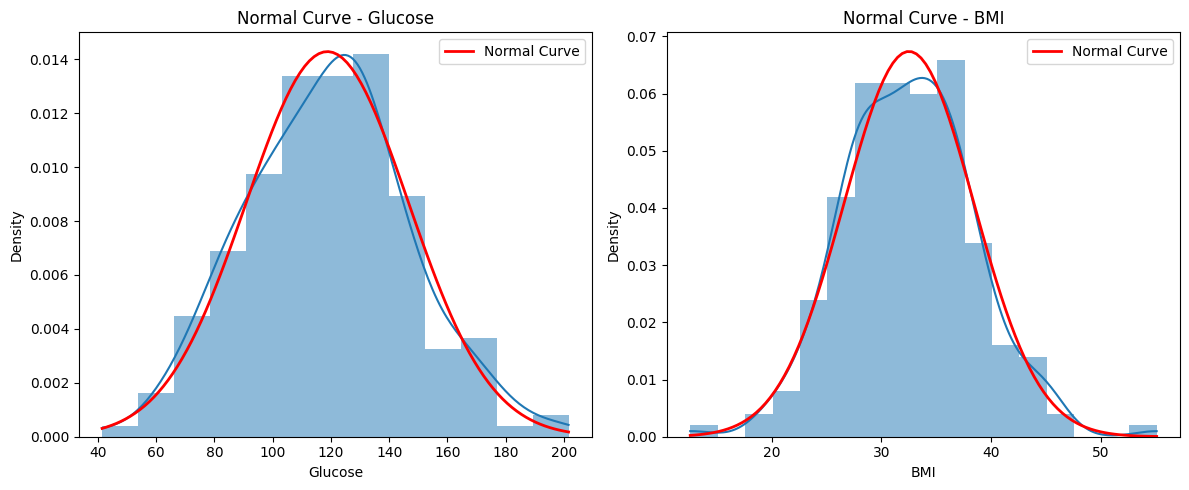


Glucose Statistics
Mean: 118.78
Standard Deviation: 27.93

BMI Statistics
Mean: 32.52
Standard Deviation: 5.92

Experiment Completed Successfully!


In [3]:
# ============================================================
# Experiment: Normal Distribution Curves for Glucose and BMI
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import os

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

file_name = "uci_diabetes (3).csv"

if os.path.exists(file_name):
    uci_diabetes = pd.read_csv(file_name)
    print("Dataset loaded successfully!")
else:
    print("CSV file not found.")
    print("Creating sample diabetes dataset for demonstration...\n")

    np.random.seed(42)

    uci_diabetes = pd.DataFrame({
        "Glucose": np.random.normal(120, 30, 200),
        "BMI": np.random.normal(32, 6, 200)
    })

# ------------------------------------------------------------
# Display Dataset Sample
# ------------------------------------------------------------

print("Dataset Sample:")
print(uci_diabetes.head())

# ------------------------------------------------------------
# Check Required Columns
# ------------------------------------------------------------

if "Glucose" not in uci_diabetes.columns or "BMI" not in uci_diabetes.columns:
    print("\nError: Dataset must contain 'Glucose' and 'BMI' columns.")
else:

    # Remove missing values
    glucose = uci_diabetes["Glucose"].dropna()
    bmi = uci_diabetes["BMI"].dropna()

    # --------------------------------------------------------
    # Plot Normal Curves
    # --------------------------------------------------------

    plt.figure(figsize=(12, 5))

    # --------------------------------------------------------
    # Normal Curve for Glucose
    # --------------------------------------------------------

    plt.subplot(1, 2, 1)

    sns.histplot(
        glucose,
        kde=True,
        stat="density",
        linewidth=0
    )

    x = np.linspace(
        glucose.min(),
        glucose.max(),
        100
    )

    plt.plot(
        x,
        norm.pdf(
            x,
            glucose.mean(),
            glucose.std()
        ),
        'r',
        linewidth=2,
        label="Normal Curve"
    )

    plt.title("Normal Curve - Glucose")
    plt.xlabel("Glucose")
    plt.ylabel("Density")
    plt.legend()

    # --------------------------------------------------------
    # Normal Curve for BMI
    # --------------------------------------------------------

    plt.subplot(1, 2, 2)

    sns.histplot(
        bmi,
        kde=True,
        stat="density",
        linewidth=0
    )

    x = np.linspace(
        bmi.min(),
        bmi.max(),
        100
    )

    plt.plot(
        x,
        norm.pdf(
            x,
            bmi.mean(),
            bmi.std()
        ),
        'r',
        linewidth=2,
        label="Normal Curve"
    )

    plt.title("Normal Curve - BMI")
    plt.xlabel("BMI")
    plt.ylabel("Density")
    plt.legend()

    # Display plots
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Display Mean and Standard Deviation
    # --------------------------------------------------------

    print("\nGlucose Statistics")
    print("Mean:", round(glucose.mean(), 2))
    print("Standard Deviation:", round(glucose.std(), 2))

    print("\nBMI Statistics")
    print("Mean:", round(bmi.mean(), 2))
    print("Standard Deviation:", round(bmi.std(), 2))

    print("\nExperiment Completed Successfully!")